# Try the DecoKiller Module

In [23]:
using Revise
using Latexify
using StatsBase
using Plots
using Plots.Measures

includet("../julia/src/DecoKiller.jl")
includet("../julia/src/utils.jl")

using .DecoKiller

# Utility function for plotting
function get_dual_intervals(mask::Vector{Int})
    # Returns vector of tuples (start, end) for both 0s and 1s
    # Uses Float64 for bounds to meet exactly in the middle (e.g., 2.5)
    
    intervals_a = Tuple{Float64, Float64}[] 
    intervals_b = Tuple{Float64, Float64}[]

    if isempty(mask); return intervals_a, intervals_b; end

    # Start the first boundary at 0.5 so the first point (1.0) is centered
    current_start = 1.5 
    current_val = mask[1]

    for i in 2:length(mask)
        if mask[i] != current_val
            # A switch happened between i-1 and i
            # We set the boundary at i - 0.5
            boundary = i - 0.5
            
            if current_val == 1 # Previously was 1 (Choice A, for example)
                push!(intervals_a, (current_start, boundary))
            else                # Previously was 0 (Choice B)
                push!(intervals_b, (current_start, boundary))
            end
            
            # Start the new run from the boundary
            current_start = boundary
            current_val = mask[i]
        end
    end

    # Close the final interval
    # Extend to length + 0.5 to cover the last point
    final_end = length(mask) + 0.5
    if current_val == 1
        push!(intervals_a, (current_start, final_end))
    else
        push!(intervals_b, (current_start, final_end))
    end

    return intervals_a, intervals_b
end

get_dual_intervals (generic function with 1 method)

In [24]:
cfg, state, logs = load_configuration("../configs/config.toml")

@info "Real noise: " cfg.real_noise.name
@info "Current choice of noise: " state.choice.current
@info "Reference recovery state σ:" cfg.sigma
@info "Starting state:" state.ρ0

# Ensure this is a valid, not-pure, state
@info "Eigenvalues: " eigvals(cfg.sigma)
@info "Trace: " tr(cfg.sigma)
@info "Purity: " tr(cfg.sigma * cfg.sigma)

┌ Info: Real noise: 
└   cfg.real_noise.name = "phase_damping"
┌ Info: Current choice of noise: 
└   state.choice.current = 2
┌ Info: Reference recovery state σ:
│   cfg.sigma =
│    2×2 Matrix{ComplexF64}:
│     0.232608+0.0im          0.1275+0.0632361im
└       0.1275-0.0632361im  0.767392+0.0im
┌ Info: Starting state:
│   state.ρ0 =
│    2×2 Matrix{ComplexF64}:
│     0.232608+0.0im          0.1275+0.0632361im
└       0.1275-0.0632361im  0.767392+0.0im
┌ Info: Eigenvalues: 
│   eigvals(cfg.sigma) =
│    2-element Vector{Float64}:
│     0.1970919602132923
└     0.8029080397867078
┌ Info: Trace: 
└   tr(cfg.sigma) = 1.0000000000000002 + 0.0im
┌ Info: Purity: 
└   tr(cfg.sigma * cfg.sigma) = 0.6835065611348516 + 0.0im


In [25]:
# 1. Apply noise (update rho1 and create intermediate rho2_)
N = state.M_total
N1 = state.noise_options[1].supermap
N2 = state.noise_options[2].supermap
Nx = cfg.real_noise.supermap

@info Nx == N1
@info Nx == N2

ρ_free = unvec(cfg.real_noise.supermap * vec(state.ρ0))
ρ_rec_ = unvec(Nx * vec(state.ρ0))
ρ1 = unvec(N1 * vec(state.ρ0))
ρ2 = unvec(N2 * vec(state.ρ0))
ρ_rec_

[ Info: false
[ Info: true


2×2 Matrix{ComplexF64}:
 0.232608+0.0im        0.121282+0.0601521im
 0.121282-0.0601521im  0.767392+0.0im

In [26]:
# 2. Recovery
model = CollisionModel(N, cfg.sigma)
ρ_rec, η = apply_collision(model, ρ_rec_)
model1 = CollisionModel(N1, cfg.sigma)
ρ1, η1 = apply_collision(model, ρ1)
model2 = CollisionModel(N2, cfg.sigma)
ρ2, η2 = apply_collision(model, ρ2)


# 3. Logging
fid_initial = fidelity(state.ρ0, ρ_rec)
fid_ref = fidelity(cfg.sigma, ρ_rec)
fid_track = fidelity(state.ρ0, ρ_free)

@info "Fidelity wrt initial state: " fid_initial
@info "Fidelity wrt reference state: " fid_ref
@info "Fidelity of free evolution: " fid_track

┌ Info: Fidelity wrt initial state: 
└   fid_initial = 0.9999999997999991
┌ Info: Fidelity wrt reference state: 
└   fid_ref = 0.9999999997999991
┌ Info: Fidelity of free evolution: 
└   fid_track = 0.9999459879290404


In [27]:
w = discrimin(η, η1, η2)
@info "Probabilities of the POVM outputs:" w

povm = sample(cfg.rng, [1, 2], Weights(w))
@info "Measurement result:" povm


┌ Info: Probabilities of the POVM outputs:
│   w =
│    2-element Vector{Float64}:
│     0.4125302612436228
└     0.587469738556377
┌ Info: Measurement result:
└   povm = 1


In [28]:
# Update the remaining state variables
if povm == 1
    append!(state.choice.c1, 1)
    append!(state.choice.c2, 0)
    state.choice.c1_count += 1
elseif povm == 2
    append!(state.choice.c1, 0)
    append!(state.choice.c2, 1)
    state.choice.c2_count += 1
end

inertia = 2
diff = state.choice.c1_count - state.choice.c2_count

if state.choice.current == 1
    if diff < -inertia
        state.choice.current = 2
    end
else
    if diff > inertia
        state.choice.current = 1
    end
end

@info "Updated choice: " state.choice.current
@info state.noise_options[state.choice.current].name

# Now we build the Petz on the belief that the noise was always that of the current choice
omega = state.noise_options[state.choice.current].supermap_noise
chosen_model = CollisionModel(state.noise_options[state.choice.current].supermap, cfg.sigma)
P = kraus_to_superop(model.kraus_rec);

┌ Info: Updated choice: 
└   state.choice.current = 2
[ Info: phase_damping


In [29]:
# Update noises
state.M_total = omega * P * state.M_total
N1 = state.noise_options[1].supermap_noise * P * N1
N2 = state.noise_options[2].supermap_noise * P * N2
# Update the truth
Nx = cfg.real_noise.supermap * P * Nx 

@info Nx == N1
@info Nx == N2

[ Info: false
[ Info: true


## Reset and add the temporal loop

In [30]:
cfg, state, logs = load_configuration("../configs/config.toml");

# Change variable names for brevity
Ox = cfg.real_noise.supermap
O1 = state.noise_options[1].supermap
O2 = state.noise_options[2].supermap
N_free = cfg.real_noise.supermap
N = state.M_total
N1 = O1
N2 = O2
Nx = Ox

@info "Real noise: " cfg.real_noise.name
@info "Current choice of noise: " state.noise_options[state.choice.current].name
@debug "Reference recovery state σ:" cfg.sigma
@debug "Starting state:" state.ρ0

variables = []

for n in 1:40
    
    # 1. Apply noise (create intermediate rho_ before recovery)
    ρ_free = unvec(N_free * vec(state.ρ0))
    ρ_rec_ = unvec(Nx * vec(state.ρ0))
    ρ1 = unvec(N1 * vec(state.ρ0))
    ρ2 = unvec(N2 * vec(state.ρ0))
    
    # 2. Recovery
    model = CollisionModel(state.choice.current == 1 ? N1 : N2, cfg.sigma)
    P = kraus_to_superop(model.kraus_rec);

    ρ_rec, η = apply_collision(model, ρ_rec_)
    model1 = CollisionModel(N1, cfg.sigma)
    ρ1, η1 = apply_collision(model, ρ1)
    model2 = CollisionModel(N2, cfg.sigma)
    ρ2, η2 = apply_collision(model, ρ2)

    # 3. Logging
    fid_initial = fidelity(state.ρ0, ρ_rec)
    fid_track = fidelity(state.ρ0, ρ_free)

    @debug "Fidelity wrt initial state: " fid_initial
    @debug "Fidelity of free evolution: " fid_track
    
    push!(logs.ref_fidelities, fid_track)
    push!(logs.fidelities, fid_initial)
    
    # 4. Update noises for the next iteration
    push!(variables, [Nx, N1, N2, P])  # save superoperators at current step
    Nx = cfg.real_noise.supermap * P * Nx
    N1 = O1 * P * N1
    N2 = O2 * P * N2
    N_free = cfg.real_noise.supermap * N_free
    
    # 4. Compare results and update guess for the next iteration
    w = discrimin(η, η1, η2)
    @debug "Probabilities of the POVM outputs:" w

    povm = sample(cfg.rng, [1, 2], Weights(w))
    @debug "Measurement result:" povm

    # Update the remaining state variables
    if povm == 1
        append!(state.choice.c1, 1)
        append!(state.choice.c2, 0)
        state.choice.c1_count += 1
    elseif povm == 2
        append!(state.choice.c1, 0)
        append!(state.choice.c2, 1)
        state.choice.c2_count += 1
    end

    inertia = 2
    diff = state.choice.c1_count - state.choice.c2_count

    # The previous-step choice changes only if there is enough inertia in the opposing choice
    # Positive `diff` means that c1 is leading, negative means that c2 is leading
    if state.choice.current == 1
        if diff < -inertia
            state.choice.current = 2
        end
    else
        if diff > inertia
            state.choice.current = 1
        end
    end
	append!(state.choice.current_choices, state.choice.current)

    @info "Updated choice: " state.choice.current
    
end

┌ Info: Real noise: 
└   cfg.real_noise.name = "phase_damping"
┌ Info: Current choice of noise: 
└   (state.noise_options[state.choice.current]).name = "amplitude_damping"
┌ Info: Updated choice: 
└   state.choice.current = 1
┌ Info: Updated choice: 
└   state.choice.current = 1
┌ Info: Updated choice: 
└   state.choice.current = 1
┌ Info: Updated choice: 
└   state.choice.current = 1
┌ Info: Updated choice: 
└   state.choice.current = 1
┌ Info: Updated choice: 
└   state.choice.current = 2
┌ Info: Updated choice: 
└   state.choice.current = 2
┌ Info: Updated choice: 
└   state.choice.current = 2
┌ Info: Updated choice: 
└   state.choice.current = 2
┌ Info: Updated choice: 
└   state.choice.current = 2
┌ Info: Updated choice: 
└   state.choice.current = 2
┌ Info: Updated choice: 
└   state.choice.current = 2
┌ Info: Updated choice: 
└   state.choice.current = 2
┌ Info: Updated choice: 
└   state.choice.current = 2
┌ Info: Updated choice: 
└   state.choice.current = 2
┌ Info: Updated ch

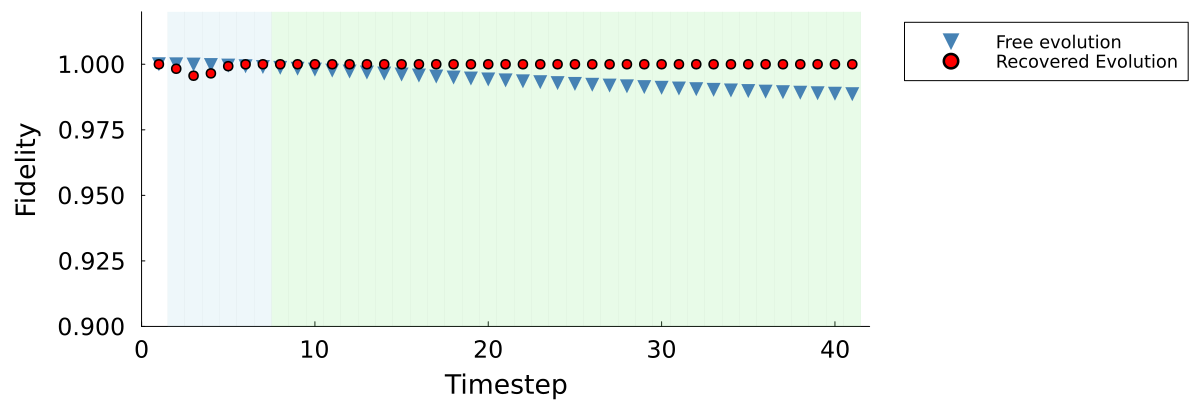

In [46]:
intervals_a, intervals_b = get_dual_intervals(state.choice.c1[1:end-1])
p = plot(
    ylim=[0.9, 1.02], xlim=[0, 42.0], size=(1200, 400), legend=:outertopright,
    titlefontsize=18,
    guidefontsize=18,
    tickfontsize=16,
    legendfontsize=12,
    grid=false,
    left_margin = 10mm, 
    bottom_margin = 9mm
)

l=0
# for (start_idx, end_idx) in intervals_a
#     vspan!(p, [start_idx, end_idx], color=:green, alpha=0.2, label= l > 0 ? "" : "Choice Ωa")
#     l += 1  # display the label once
# end
# l = 0
# for (start_idx, end_idx) in intervals_b
#     vspan!(p, [start_idx, end_idx], color=:orange, alpha=0.2, label= l > 0 ? "" : "Choice Ωb")
#     l += 1  # display the label once
# end
# vline!(p, collect(0:length(logs.ref_fidelities)) .+ 1.5, linestyle=:dash, color=:lightgrey, lw=1, label=nothing)

for i in 1:(length(state.choice.current_choices)-1)
	band_color = state.choice.current_choices[i] == 1 ? :lightblue : :lightgreen

	vspan!(p, [i+0.5, i+1.5], color=band_color, alpha=0.2, label=nothing)
end

scatter!(
        [[1.0; logs.ref_fidelities] [1.0; logs.fidelities]],
        labels=["Free evolution" "Recovered Evolution"],
        xlabel="Timestep", ylabel="Fidelity",
        shape = [:dtriangle :circle],
        markercolor = [:steelblue :red],
        markerstrokecolor = [:steelblue :transparent],
        markerstrokewidth = 2, markersize = [7 5],
)

savefig(p, "../visualization/adaptive_recovery_ampdamp_phasedamp.png")
savefig(p, "../visualization/adaptive_recovery_ampdamp_phasedamp.pdf")
display(p)

In [32]:
state.choice.current_choices

41-element Vector{Int64}:
 1
 1
 1
 1
 1
 1
 2
 2
 2
 2
 ⋮
 2
 2
 2
 2
 2
 2
 2
 2
 2

## Follow the Evolution

In [33]:
Nxs = [v[1] for v in variables]
N1s = [v[2] for v in variables]
N2s = [v[3] for v in variables]
Ps = [v[4] for v in variables]

# Simulate step 1
N_free = Nxs[1]
ρ_free = unvec(N_free * vec(state.ρ0))
ρ_rec_ = unvec(Nxs[1] * vec(state.ρ0))
ρ_rec = unvec(Ps[1] * vec(ρ_rec_))


fid_track = fidelity(state.ρ0, ρ_free)
fid_rec = fidelity(state.ρ0, ρ_rec)

choice = state.choice.c1[1] == 1 ? "Na" : "Nb"
println("Choice of noise to recover:\t $choice")
println("Fidelity of free evolution:\t $fid_track")
println("Fidelity after recovery:\t $fid_rec")

Choice of noise to recover:	 Na
Fidelity of free evolution:	 0.999962176390856
Fidelity after recovery:	 0.9982840023696429


In [34]:
# Step 2
step = 2
ρ_free = unvec((N_free)^step * vec(state.ρ0))
ρ_rec_ = unvec(Nxs[step] * vec(state.ρ0))
ρ_rec = unvec(Ps[step] * vec(ρ_rec_))

fid_track = fidelity(state.ρ0, ρ_free)
fid_rec = fidelity(state.ρ0, ρ_rec)

choice = state.choice.c1[step] == 1 ? "Na" : "Nb"
println("Choice of noise to recover:\t $choice")
println("Fidelity of free evolution:\t $fid_track")
println("Fidelity after recovery:\t $fid_rec")

Choice of noise to recover:	 Na
Fidelity of free evolution:	 0.9998564030851768
Fidelity after recovery:	 0.9956242523092853


In [35]:
# Step 3
step = 3
ρ_free = unvec((N_free)^step * vec(state.ρ0))
ρ_rec_ = unvec(Nxs[step] * vec(state.ρ0))
ρ_rec = unvec(Ps[step] * vec(ρ_rec_))

fid_track = fidelity(state.ρ0, ρ_free)
fid_rec = fidelity(state.ρ0, ρ_rec)

choice = state.choice.c1[step] == 1 ? "Na" : "Nb"
println("Choice of noise to recover:\t $choice")
println("Fidelity of free evolution:\t $fid_track")
println("Fidelity after recovery:\t $fid_rec")

Choice of noise to recover:	 Nb
Fidelity of free evolution:	 0.9996931522995907
Fidelity after recovery:	 0.996514475000585


In [36]:
# Step 4
step = 4
ρ_free = unvec((N_free)^step * vec(state.ρ0))
ρ_rec_ = unvec(Nxs[step] * vec(state.ρ0))
ρ_rec = unvec(Ps[step] * vec(ρ_rec_))

fid_track = fidelity(state.ρ0, ρ_free)
fid_rec = fidelity(state.ρ0, ρ_rec)

choice = state.choice.c1[step] == 1 ? "Na" : "Nb"
println("Choice of noise to recover:\t $choice")
println("Fidelity of free evolution:\t $fid_track")
println("Fidelity after recovery:\t $fid_rec")

Choice of noise to recover:	 Nb
Fidelity of free evolution:	 0.9994816052247372
Fidelity after recovery:	 0.9992645911156652


In [37]:
# Step 5
step = 5
ρ_free = unvec((N_free)^step * vec(state.ρ0))
ρ_rec_ = unvec(Nxs[step] * vec(state.ρ0))
ρ_rec = unvec(Ps[step] * vec(ρ_rec_))

fid_track = fidelity(state.ρ0, ρ_free)
fid_rec = fidelity(state.ρ0, ρ_rec)

choice = state.choice.c1[step] == 1 ? "Na" : "Nb"
println("Choice of noise to recover:\t $choice")
println("Fidelity of free evolution:\t $fid_track")
println("Fidelity after recovery:\t $fid_rec")

Choice of noise to recover:	 Nb
Fidelity of free evolution:	 0.9992298086940122
Fidelity after recovery:	 0.9999729636695692


In [38]:
# Step 6
step = 6
ρ_free = unvec((N_free)^step * vec(state.ρ0))
ρ_rec_ = unvec(Nxs[step] * vec(state.ρ0))
ρ_rec = unvec(Ps[step] * vec(ρ_rec_))

fid_track = fidelity(state.ρ0, ρ_free)
fid_rec = fidelity(state.ρ0, ρ_rec)

choice = state.choice.c1[step] == 1 ? "Na" : "Nb"
println("Choice of noise to recover:\t $choice")
println("Fidelity of free evolution:\t $fid_track")
println("Fidelity after recovery:\t $fid_rec")

Choice of noise to recover:	 Nb
Fidelity of free evolution:	 0.9989448113588523
Fidelity after recovery:	 0.9999997719991308


In [39]:
first_change = findfirst(x -> x == 1, state.choice.current_choices)
display(latexify(chop!(Ps[first_change - 1])))
display(latexify(chop!(Ps[first_change])))
display(latexify(chop!(Ps[first_change + 1])))

BoundsError: BoundsError: attempt to access 40-element Vector{Matrix{ComplexF64}} at index [0]

In [40]:
display(latexify(N1s[1]))
display(latexify(N2s[1]))

L"\begin{equation}
\left[
\begin{array}{cccc}
1.0+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0951625819640405+0.0\mathit{i} \\
0.0\mathit{i} & 0.951229424500714+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.951229424500714+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.9048374180359596+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
1.0+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.951229424500714+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.951229424500714+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 1.0000000000000002+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

In [41]:
# Suppose we want to recover Noise 2 (true noise)
display(latexify(chop!(N2s[8])))
# What state do this maps to?
ρ = unvec(N2s[8] * vec(state.ρ0))
display(latexify(chop!(ρ)))
display("Purity: $(tr(ρ * ρ))")
model = CollisionModel(N2s[8], cfg.sigma)
P = kraus_to_superop(model.kraus_rec);
display(latexify(chop!(P)))
# What does the recovery do?
ρ = unvec(P * N2s[8] * vec(state.ρ0))
display(latexify(chop!(ρ)))
display("Purity: $(tr(ρ * ρ))")

"\\begin{equation}\n\\left[\n\\begin{array}{cccc}\n0.5264728498289575+0.0\\mathit{i} & -2.0846608135236045e-7-4.3254277799661737e-7\\mathit{i} & -2.0846608135292974e-7+4.325427779944665e-7\\mathit{i} & 0.5264726836170587+0.0\\mathit{i} \\\\\n-0.05056618311933768+0.10491892563701664\\ma" ⋯ 303 bytes ⋯ "-0.050565783303043586-0.10491809606489078\\mathit{i} \\\\\n0.4735271487950695+0.0\\mathit{i} & 2.083929513984271e-7+4.3239104068414087e-7\\mathit{i} & 2.083929513979122e-7-4.323910406860829e-7\\mathit{i} & 0.4735273148050443+0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

L"\begin{equation}
\left[
\begin{array}{cc}
0.5264728887043448+0.0\mathit{i} & -0.05056627714949987-0.10491912073862383\mathit{i} \\
-0.05056627714949987+0.10491912073862383\mathit{i} & 0.47352710986531366+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

"Purity: 0.5285315668807462 + 0.0im"

"\\begin{equation}\n\\left[\n\\begin{array}{cccc}\n0.5264728617432619+0.0\\mathit{i} & -1.9707396227419682e-7-4.089054605471709e-7\\mathit{i} & -1.9707396227419682e-7+4.089054605471709e-7\\mathit{i} & 0.5264726967563559+0.0\\mathit{i} \\\\\n-0.0531587954523454+0.11029829350289827\\math" ⋯ 303 bytes ⋯ "53158378009356334-0.11029742735743849\\mathit{i} \\\\\n0.4735271380558641+0.0\\mathit{i} & 1.9705251191187712e-7+4.0886095337144823e-7\\mathit{i} & 1.9705251191187712e-7-4.0886095337144823e-7\\mathit{i} & 0.47352730302031026+0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

L"\begin{equation}
\left[
\begin{array}{cc}
0.5264728885990492+0.0\mathit{i} & -0.05315886560797693-0.11029843906764203\mathit{i} \\
-0.05315886560797693+0.11029843906764203\mathit{i} & 0.47352710977060863+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

"Purity: 0.5313848474245035 + 0.0im"

In [42]:
# Insted, if we were to recover Noise 1 (wrong noise)
display(latexify(chop!(N1s[8])))
# What state do this maps to?
ρ = unvec(N1s[8] * vec(state.ρ0))
display(latexify(chop!(ρ)))
display("Purity: $(tr(ρ * ρ))")
model = CollisionModel(N1s[8], cfg.sigma)
P = kraus_to_superop(model.kraus_rec);
display(latexify(chop!(P)))
# What does the recovery do?
ρ = unvec(P * N1s[8] * vec(state.ρ0))
display(latexify(chop!(ρ)))
display("Purity: $(tr(ρ * ρ))")

"\\begin{equation}\n\\left[\n\\begin{array}{cccc}\n0.5715377337847936+0.0\\mathit{i} & -1.875639613062645e-7-3.8917331957596526e-7\\mathit{i} & -1.875639613062645e-7+3.8917331957794403e-7\\mathit{i} & 0.5715376296291654+0.0\\mathit{i} \\\\\n-0.05057205003350983+0.10493109879887651\\mat" ⋯ 302 bytes ⋯ "050571772973568636-0.10493052393184928\\mathit{i} \\\\\n0.4284622648519252+0.0\\mathit{i} & 1.8749099048198434e-7+3.8902191244727276e-7\\mathit{i} & 1.8749099048198434e-7-3.890219124457821e-7\\mathit{i} & 0.42846236884529715+0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

L"\begin{equation}
\left[
\begin{array}{cc}
0.5715377902560743+0.0\mathit{i} & -0.05057220071434051-0.104931411444006\mathit{i} \\
-0.05057220071434051+0.104931411444006\mathit{i} & 0.42846220834496995+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

"Purity: 0.5373716068560905 + 0.0im"

"\\begin{equation}\n\\left[\n\\begin{array}{cccc}\n0.5264728639110559+0.0\\mathit{i} & -1.3576376044210914e-7-2.81693950637818e-7\\mathit{i} & -1.3576376044210914e-7+2.81693950637818e-7\\mathit{i} & 0.526472753242278+0.0\\mathit{i} \\\\\n-0.05315877132086331+0.11029824343289064\\mathit" ⋯ 295 bytes ⋯ " & -0.0531583620443188-0.11029739423184969\\mathit{i} \\\\\n0.4735271359037131+0.0\\mathit{i} & 1.3574189745846343e-7+2.81648587369121e-7\\mathit{i} & 1.3574189745846343e-7-2.81648587369121e-7\\mathit{i} & 0.4735272465106381+0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

L"\begin{equation}
\left[
\begin{array}{cc}
0.5264728886059866+0.0\mathit{i} & -0.05315886560959812-0.11029843907100578\mathit{i} \\
-0.05315886560959812+0.11029843907100578\mathit{i} & 0.4735271097950564+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

"Purity: 0.5313848474567904 + 0.0im"

In [43]:
display(latexify(Ps[1]))
display(latexify(Ps[2]))
display(latexify(Ps[3]))
display(latexify(Ps[4]))
display(latexify(Ps[5]))

"\\begin{equation}\n\\left[\n\\begin{array}{cccc}\n0.919169438743779+0.0\\mathit{i} & -0.002077612819965882-0.004310804009985889\\mathit{i} & -0.002077612819965882+0.004310804009985889\\mathit{i} & 4.8411294219227684e-5+0.0\\mathit{i} \\\\\n-0.0068008181688009785+0.014110903606059114\\" ⋯ 344 bytes ⋯ " -0.0023172941479721915-0.004808114779326097\\mathit{i} \\\\\n0.080830561070992+0.0\\mathit{i} & 0.002077612798105904+0.004310803964628567\\mathit{i} & 0.002077612798105904-0.004310803964628567\\mathit{i} & 0.999951588458702+0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

"\\begin{equation}\n\\left[\n\\begin{array}{cccc}\n0.8520888966434336+0.0\\mathit{i} & -0.0036147530272162345-0.007500190456606875\\mathit{i} & -0.0036147530272162345+0.007500190456606875\\mathit{i} & 0.08760319413754687+0.0\\mathit{i} \\\\\n-0.012649428391171221+0.02624608690736741\\m" ⋯ 340 bytes ⋯ "0.004848729481152579-0.010060547513868432\\mathit{i} \\\\\n0.147911103171339+0.0\\mathit{i} & 0.0036147530053563075+0.007500190411249729\\mathit{i} & 0.0036147530053563075-0.007500190411249729\\mathit{i} & 0.9123968056153753+0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

"\\begin{equation}\n\\left[\n\\begin{array}{cccc}\n0.75023505921613+0.0\\mathit{i} & -0.005482331001007463-0.011375196685395573\\mathit{i} & -0.005482331001007463+0.011375196685395573\\mathit{i} & 0.22112874284924944+0.0\\mathit{i} \\\\\n-0.022040173141642666+0.0457307857588863\\mathit" ⋯ 335 bytes ⋯ "-0.010209208983603307-0.021182916567690148\\mathit{i} \\\\\n0.24976494059864032+0.0\\mathit{i} & 0.005482330979147649+0.011375196640038335\\mathit{i} & 0.005482330979147649-0.011375196640038335\\mathit{i} & 0.778871256903672+0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

"\\begin{equation}\n\\left[\n\\begin{array}{cccc}\n0.631878326601581+0.0\\mathit{i} & -0.006356786042329341-0.013189588790823895\\mathit{i} & -0.006356786042329341+0.013189588790823895\\mathit{i} & 0.37791129737023804+0.0\\mathit{i} \\\\\n-0.034370241575635944+0.0713142380450185\\mathi" ⋯ 328 bytes ⋯ " -0.020652188463928214-0.04285087961997904\\mathit{i} \\\\\n0.3681216732131909+0.0\\mathit{i} & 0.006356786020469352+0.013189588745466843\\mathit{i} & 0.006356786020469352-0.013189588745466843\\mathit{i} & 0.6220887023826831+0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

"\\begin{equation}\n\\left[\n\\begin{array}{cccc}\n0.5494895022450321+0.0\\mathit{i} & -0.004410404730670829-0.009151074837393164\\mathit{i} & -0.004410404730670829+0.009151074837393164\\mathit{i} & 0.49024804493849683+0.0\\mathit{i} \\\\\n-0.0457490824715885+0.0949240042593349\\mathit" ⋯ 327 bytes ⋯ "{i} & -0.03623135356021315-0.07517582810118695\\mathit{i} \\\\\n0.45051049756974+0.0\\mathit{i} & 0.004410404708810649+0.00915107479203607\\mathit{i} & 0.004410404708810649-0.00915107479203607\\mathit{i} & 0.5097519548144238+0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"